In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import torch
import torch.nn as nn
import torch.optim as optim

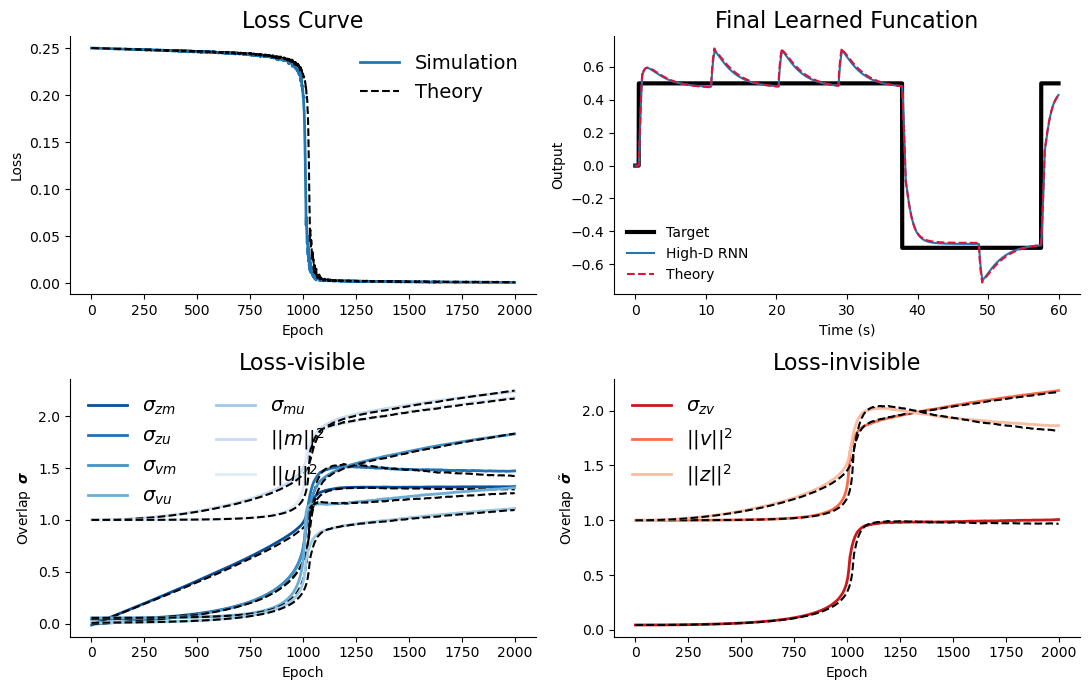

In [2]:
###################################
# --- 1. CONFIGURATION & TASK --- #
###################################
N, dt, t_max = 1_000, 0.025, 20
lr, num_epochs, batch_size = 5e-2, 2_000, 10

def normalize(x):
    return x / torch.norm(x, p=2)

def flip_flop(t_max, dt, batch_size, 
              stim_range=(4.0, 10.0), 
              input_amp=1.0,          
              target_amp=0.5, 
              stimulus_duration=0.5,
              use_torch=False):
    
    delay_duration = 2.0
    stim_min, stim_max = stim_range
    
    stim_d = int(stimulus_duration / dt)
    ded  = int(delay_duration / dt)
    T      = int(t_max / dt)

    if use_torch:
        x = torch.zeros((batch_size, T, 1), dtype=torch.float32)
        y = torch.zeros((batch_size, T, 1), dtype=torch.float32)
        m = torch.zeros((batch_size, T, 1), dtype=torch.float32)
    else:
        x = np.zeros((batch_size, T, 1), dtype=np.float32)
        y = np.zeros((batch_size, T, 1), dtype=np.float32)
        m = np.zeros((batch_size, T, 1), dtype=np.float32)

    for b in range(batch_size):
        curr_target = 0.0
        last_delay_end = 0
        had_pulse = False

        while True:
            if not had_pulse:
                wait = int(0.5 / dt)
            else:
                if use_torch:
                    wait_val = (torch.rand(1) * (stim_max - stim_min) + stim_min).item()
                else:
                    wait_val = np.random.uniform(stim_min, stim_max)
                wait = int(wait_val / dt)

            pulse_start = last_delay_end + wait
            if pulse_start >= T: break

            if had_pulse and last_delay_end < pulse_start:
                m[b, last_delay_end:pulse_start, 0] = 1.0

            pulse_end = min(pulse_start + stim_d, T)
            delay_end = min(pulse_end + ded, T)

            if use_torch:
                sign = 1.0 if torch.rand(1).item() > 0.5 else -1.0
            else:
                sign = np.random.choice([1.0, -1.0])

            x[b, pulse_start:pulse_end, 0] = float(sign)
            curr_target = 1.0 if sign > 0 else -1.0
            y[b, pulse_start:, 0] = curr_target
            m[b, max(0, pulse_start-1):delay_end, 0] = 0.0

            had_pulse = True
            last_delay_end = delay_end

        if had_pulse and last_delay_end < T:
            m[b, last_delay_end:T, 0] = 1.0

    x *= input_amp
    y *= target_amp
    return x, y, m

def masked_mse(pred, target, mask, factor=1, eps=1e-8):
    
    num = ((pred - target) ** 2) * mask * factor
    den = mask.sum().clamp_min(eps)
    loss = num.sum() / den
    return loss

##############################################
# --- 2. HIGH-DIMENSIONAL RNN SIMULATION --- #
##############################################
def erf_alpha(alpha):
    return lambda x: torch.erf(alpha * x)
    
class low_rank_rnn(nn.Module):
    def __init__(self, N=100, scale=1, rank=1, phi='erf', dt=1.0, tau=1.0):
        
        super().__init__()
        self.N, self.dt, self.tau = N, dt, tau
        self.alpha = np.sqrt(np.pi) / 2.0
        self.phi = erf_alpha(self.alpha)
        
        self.m = nn.Parameter(scale * torch.randn(N, 1), requires_grad=True)
        self.u = nn.Parameter(scale * torch.randn(N, rank), requires_grad=True)
        self.v = nn.Parameter(scale * torch.randn(N, rank), requires_grad=True)
        self.z = nn.Parameter(scale * torch.randn(N, 1), requires_grad=True)

    def forward(self, x_t, h):
        W = (1.0 / self.N) * (self.u @ self.v.T) 
        phi_h = self.phi(h) 
        h_update = W @ phi_h + self.m @ x_t
        h = h + (self.dt / self.tau) * (-h + h_update)
        y = (1.0 / self.N) * (self.z.T @ phi_h) 
                
        return y, h

class RNN_Sim:
    def __init__(self):
        # Initialization
        self.rnn = low_rank_rnn(N=N, scale=1, rank=1, phi='erf', dt=dt, tau=1.0)
        m, u, v, z = [normalize(torch.randn(N, 1)) * np.sqrt(N) for _ in range(4)]
        with torch.no_grad():    
            self.rnn.m.copy_(m)
            self.rnn.u.copy_(u)
            self.rnn.v.copy_(v)
            self.rnn.z.copy_(z)
            
        self.optimizer = optim.SGD(self.rnn.parameters(), lr=N*lr)

    def train(self):
        history = {'loss': [], 'overlaps': []}
        for epoch in range(num_epochs):
            x, y, mask = flip_flop(t_max, dt, batch_size, stim_range=(4.0,10.0), input_amp=1.0, target_amp=0.5, use_torch=True) 
            B, T, _ = x.shape
            h = torch.zeros(self.rnn.N, B)  
            y_hat = []
            for t in range(T):
                x_t = x[:, t, :].T                 
                y_t, h = self.rnn(x_t, h)               
                y_hat.append(y_t.T.unsqueeze(1))  
                
            y_hat = torch.cat(y_hat, dim=1)            
            loss = masked_mse(y_hat, y, mask)
            history['loss'].append(loss.item())

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            # Record Overlaps
            m, u, v, z = self.rnn.m.flatten(), self.rnn.u.flatten(), self.rnn.v.flatten(), self.rnn.z.flatten()
            history['overlaps'].append([
                    (z @ m / N).item(), (z @ u / N).item(), (v @ m / N).item(), 
                    (v @ u / N).item(), (m @ u / N).item(), (m @ m / N).item(), (u @ u / N).item(), # "Visible"
                    (z @ v / N).item(), (v @ v / N).item(), (z @ z / N).item() # "Invisible"
                 
            ])
            
        return history
        
###############################################
# --- 3. LOW-DIMENSIONAL THEORY (10D ODE) --- #
###############################################
class effective_rnn_from_scaler_erf(nn.Module):
    """
    2D effective rank-1 RNN with erf non-linearity
    """
    def __init__(self, zm, zu, vm, vu, mu, mm, uu, dt, eps=1e-8):
        super().__init__()
        self.dt = dt
        self.eps = eps

        # overlaps (scalars, trainable)
        self.zm = nn.Parameter(torch.tensor(zm, dtype=torch.float32))
        self.zu = nn.Parameter(torch.tensor(zu, dtype=torch.float32))
        self.vm = nn.Parameter(torch.tensor(vm, dtype=torch.float32))
        self.vu = nn.Parameter(torch.tensor(vu, dtype=torch.float32))
        self.mu = nn.Parameter(torch.tensor(mu, dtype=torch.float32))
        self.mm = nn.Parameter(torch.tensor(mm, dtype=torch.float32))
        self.uu = nn.Parameter(torch.tensor(uu, dtype=torch.float32))

        # basis input vector m = [1,0]^T and a placeholder z buffer
        self.register_buffer("m", torch.tensor([[1.0], [0.0]]))   # (2,1)
        self.register_buffer("zbuf", torch.zeros((2, 1)))         # (2,1)

    def erf_gain(self, Delta):
        """
        phi(x) = erf( (sqrt(pi)/2) x )
        G(Delta) = <phi'(sqrt(Delta) z)>
        Delta: (B,) or scalar
        """
        return 1.0 / torch.sqrt(1.0 + (torch.pi / 2.0) * Delta + self.eps)

    def forward(self, x_t, k):
        """
        x_t: (1,B) or (B,1) or scalar
        k:   (2,B)
        returns:
          y: (1,B)
          k: (2,B)
        """
        # ---- normalize x_t to (1,B)
        if x_t.ndim == 0:
            x_t = x_t.view(1, 1)
        elif x_t.ndim == 1:
            # could be (B,) -> (1,B)
            x_t = x_t.view(1, -1)
        elif x_t.ndim == 2:
            # (B,1) -> (1,B), (1,B) keep
            if x_t.shape[0] != 1 and x_t.shape[1] == 1:
                x_t = x_t.T
            # else assume already (1,B)
        else:
            raise ValueError(f"x_t must be scalar/1D/2D, got shape {tuple(x_t.shape)}")

        # ---- k must be (2,B)
        if k.ndim != 2 or k.shape[0] != 2:
            raise ValueError(f"k must have shape (2,B), got {tuple(k.shape)}")

        k_m = k[0, :]   # (B,)
        k_u = k[1, :]   # (B,)

        Delta = (self.mm * k_m**2 + self.uu * k_u**2 + 2.0 * self.mu * k_m * k_u)  # (B,)

        G = self.erf_gain(Delta)                           # (B,)
        s = (self.vm * k_m + self.vu * k_u) * G            # (B,)

        # k_update = [0; s] + m*x_t  -> (2,B)
        k_update = torch.stack([torch.zeros_like(s), s], dim=0) + self.m * x_t
        k = k + self.dt * (-k + k_update)

        z = self.zbuf.clone()
        z[0, 0] = self.zm
        z[1, 0] = self.zu
        y = (z.T @ k) * G  
        
        return y, k

def integrate_theory(initial_overlaps):
    """Integrates the 10 coupled ODEs describing overlap learning dynamics."""
    
    sig_zm, sig_zu, sig_vm, sig_vu, sig_mu, mm, uu, sig_zv, vv, zz = initial_overlaps
    history = {'loss': [], 'overlaps': []}
    
    for epoch in range(num_epochs):
        history['overlaps'].append((sig_zm, sig_zu, sig_vm, sig_vu, sig_mu, mm, uu, sig_zv, vv, zz))

        eff_rnn = effective_rnn_from_scaler_erf(sig_zm, sig_zu, sig_vm, sig_vu, sig_mu, mm, uu, dt=dt)
        optimizer  = torch.optim.SGD(eff_rnn.parameters(), lr=lr) 

        x, y, mask = flip_flop(t_max, dt, batch_size, stim_range=(4.0,10.0), input_amp=1.0, target_amp=0.5, use_torch=True) 
        B, T, _ = x.shape
        h = torch.zeros(2, B)     
                        
        y_hat = []                
        for t in range(T):
            x_t = x[:, t, :].T  
            y_t, h = eff_rnn(x_t, h)
            y_hat.append(y_t.T.unsqueeze(1))   

        y_hat = torch.cat(y_hat, dim=1)            
        loss = masked_mse(y_hat, y, mask)
        history['loss'].append(loss.item())

        optimizer.zero_grad()
        loss.backward()
    
        d_zm, d_zu = eff_rnn.zm.grad.item(),eff_rnn.zu.grad.item() 
        d_vm, d_vu = eff_rnn.vm.grad.item(),eff_rnn.vu.grad.item()
        d_mu = eff_rnn.mu.grad.item()
        d_mm, d_uu = eff_rnn.mm.grad.item(),eff_rnn.uu.grad.item()
        
        scale = 1.0    
        sig_zm -= scale * lr * ( (mm + zz) * d_zm + sig_mu * d_zu + sig_zv * d_vm + sig_zu * d_mu + 2.0 * sig_zm * d_mm )
        sig_zu -= scale * lr * ( sig_mu * d_zm + (uu + zz) * d_zu + sig_zv * d_vu + sig_zm * d_mu + 2.0 * sig_zu * d_uu )
        sig_vm -= scale * lr * ( (mm + vv) * d_vm + sig_mu * d_vu + sig_zv * d_zm + sig_vu * d_mu + 2.0 * sig_vm * d_mm )
        sig_vu -= scale * lr * ( sig_mu * d_vm + (uu + vv) * d_vu + sig_zv * d_zu + sig_vm * d_mu + 2.0 * sig_vu * d_uu )
        
        sig_mu -= scale * lr * ( sig_zu * d_zm + sig_zm * d_zu + sig_vu * d_vm + sig_vm * d_vu + (mm + uu) * d_mu + 2.0 * sig_mu * (d_mm + d_uu) )
        sig_zv -= scale * lr * ( sig_vm * d_zm + sig_vu * d_zu + sig_zm * d_vm + sig_zu * d_vu )
    
        mm -= scale * lr * ( 2.0 * (sig_zm * d_zm + sig_vm * d_vm + sig_mu * d_mu + 2.0 * mm * d_mm ) )
        uu -= scale * lr * ( 2.0 * (sig_zu * d_zu + sig_vu * d_vu + sig_mu * d_mu + 2.0 * uu * d_uu ) )
        vv -= scale * lr * ( 2.0 * (sig_vm * d_vm + sig_vu * d_vu) ) 
        zz -= scale * lr * ( 2.0 * (sig_zm * d_zm + sig_zu * d_zu) )

    return history

#####################
# --- 4. TRAIN  --- #
#####################
sim = RNN_Sim()
sim_res = sim.train()
the_res = integrate_theory(initial_overlaps=sim_res['overlaps'][0])

#######################
# --- 5. PLOTTING --- #
#######################
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax = ax.flatten()
epochs_axis = np.arange(num_epochs)

# A. Loss Curve
ax[0].plot(sim_res['loss'], lw=2, label='Simulation')
ax[0].plot(the_res['loss'], '--k', label='Theory')
ax[0].set_title('Loss Curve', size=16)
ax[0].set_ylabel('Loss')
ax[0].legend(frameon=False, fontsize=14)

# B. Final Learned Funcation
@torch.no_grad()
def run_rollout(model, x, h_init):
    """Generic rollout"""
    B, T, _ = x.shape
    h = h_init
    ys = []
    for t in range(T):
        y_t, h = model(x[:, t, :].T, h) 
        ys.append(y_t.T.unsqueeze(1))   
    return torch.cat(ys, dim=1)         

x, y, mask = flip_flop(3*t_max, dt, batch_size=1, use_torch=True)
t_axis = np.arange(x.shape[1]) * dt

# High-D Rollout
y_highd = run_rollout(sim.rnn, x, h_init=torch.zeros(sim.rnn.N, 1))

# Effective Theory Rollout 
ovs = the_res['overlaps'][-1]
eff_rnn = effective_rnn_from_scaler_erf(*ovs[:7], dt=dt) # Unpacks first 7 params
y_theory = run_rollout(eff_rnn, x, h_init=torch.zeros(2, 1))

y_target = y.squeeze().numpy()
highd_out   = y_highd.squeeze().numpy()
theory_out = y_theory.squeeze().numpy()

ax[1].plot(t_axis, y_target, color='k',  lw=3, label='Target')
ax[1].plot(t_axis, highd_out,  label='High-D RNN')
ax[1].plot(t_axis, theory_out, color='crimson', ls='--', label='Theory')
ax[1].set_title('Final Learned Funcation', size=16)

ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Output')
ax[1].legend(frameon=False,loc='best')

# C. Loss-Visible Overlaps
labels_v = [r'$\sigma_{zm}$', r'$\sigma_{zu}$', r'$\sigma_{vm}$', r'$\sigma_{vu}$',r'$\sigma_{mu}$',r'$||m||^2$', r'$||u||^2$']
ov_sim = np.array(sim_res['overlaps'])
ov_th = np.array(the_res['overlaps'])
cols = sns.color_palette('Blues_r', n_colors=7)
for i in range(7):
    ax[2].plot(epochs_axis, ov_sim[:, i], lw=2, label=labels_v[i], color=cols[i])
    ax[2].plot(epochs_axis, ov_th[:, i], '--k')
ax[2].set_title('Loss-visible', size=16)
ax[2].set_ylabel(r'$\text{Overlap}\,\,\, \boldsymbol{\sigma}$')
ax[2].legend(ncol=2, frameon=False, fontsize=14)

# D. Loss-Invisible Overlaps
labels_inv = [r'$\sigma_{zv}$', r'$||v||^2$', r'$||z||^2$']
cols = sns.color_palette('Reds_r', n_colors=3)
for i in range(7, 10):
    ax[3].plot(epochs_axis, ov_sim[:, i], lw=2, label=labels_inv[i-7], color=cols[i-7])
    ax[3].plot(epochs_axis, ov_th[:, i], '--k')
ax[3].set_title('Loss-invisible', size=16)
ax[3].set_ylabel(r'$\text{Overlap}\,\,\, \tilde{\boldsymbol{\sigma}}$')
ax[3].legend(frameon=False, fontsize=14)

for a in [ax[0],ax[2],ax[3]]:
    a.set_xlabel('Epoch')
    # a.set_xscale('log')

sns.despine()
plt.tight_layout()
plt.show()
